In [1]:
import numpy as np
import matplotlib.pyplot as plt


[55, 87, 62, 43, 13, 97, 66, 88, 83, 39]
Execution time: 0.051512956619262695 seconds


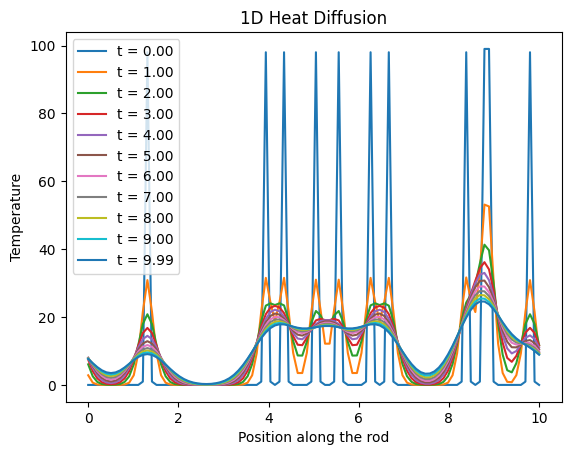

In [22]:
# Parameters
L     = 10  # Length of the rod
nx    = 100  # Number of spatial points
dx    = L / (nx - 1)  # Spatial step size
alpha = 0.01  # Thermal diffusivity constant
dt    = 0.01  # Time step
nt    = 1000  # Number of time steps

# Create the spatial domain
x     = np.linspace(0, L, nx)

# Initial temperature distribution
u     = np.zeros(nx)
u[int(nx / 2)] = 100  # Add a heat source in the middle

from random import randint

posi = [randint(0, 100) for p in range(0, 10)]
print(posi)
u[posi] =100

# define diffusion kernel
I                = np.eye(np.size(u))
Diffusion_kernel = np.roll(I, 1,axis=0) -2*I + np.roll(I, -1,axis=0)

import time

# get the start time
st = time.time()


for t in range(nt):
    u = u + alpha* Diffusion_kernel.dot(u)/(dx**2)*dt
    if t % 100 == 0 or t == nt - 1:
        plt.plot(x, u, label=f't = {t * dt:.2f}')

et = time.time()

# get the execution time
elapsed_time = et - st
print('Execution time:', elapsed_time, 'seconds')

# Plotting the results
plt.title("1D Heat Diffusion")
plt.xlabel("Position along the rod")
plt.ylabel("Temperature")
plt.legend()
plt.show()

[55, 87, 47, 22, 15, 44, 16, 43, 21, 28]
(100,)
Execution time: 0.16988301277160645 seconds


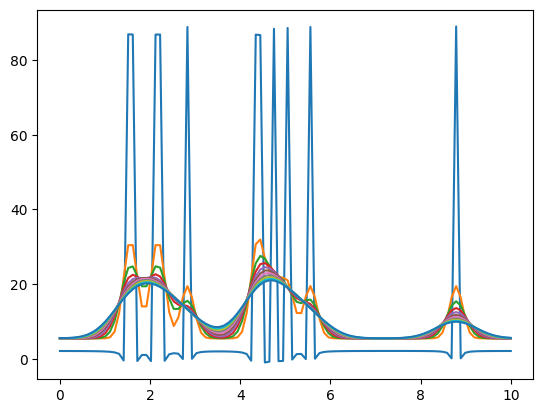

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
nx = 100  # Number of spatial points
L = 10  # Length of the rod
dx = L / (nx - 1)  # Spatial step size
alpha = 0.01  # Thermal diffusivity constant
dt = 0.01  # Time step
nt = 1000  # Number of time steps

# Spatial domain
x = np.linspace(0, L, nx)

# Initialize temperature distribution with a heat source in the middle
u = np.zeros(nx)
u[int(nx / 2)] = 100  # Add a heat source in the middle
u[int(nx / 2)] = 100  # Add a heat source in the middle

from random import randint

posi = [randint(0, 100) for p in range(0, 10)]
print(posi)
u[posi] =100

# Fourier Transform functions
def dft(y):
    N = len(y)
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, y)

def idft(Y):
    N = len(Y)
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(2j * np.pi * k * n / N)
    return np.dot(M, Y) / N

# Second order differentiation operator in the Fourier domain
def second_order_diff_op(N):
    n = np.arange(N)
    k = n.reshape((N, 1))
    return (2j * np.pi * k / N) ** 2

# Initialize u_hat and get the differential operator
u_hat   = dft(u)
print(np.shape(u_hat))
diff_op = second_order_diff_op(nx)
I       = np.eye(np.size(u))
np.fill_diagonal(I, diff_op)


import time

# get the start time
st = time.time()
#print(np.shape(diff_op))
# Time integration using DFT approach
for t in range(nt):
    u_hat = u_hat + alpha * I.dot( u_hat) * dt*L**2

    # Plot at certain intervals
    if t % 100 == 0 or t == nt - 1:
        u_back = idft(u_hat)
        plt.plot(x, np.real(u_back), label=f't = {t * dt:.2f}')

et = time.time()

# get the execution time
elapsed_time = et - st
print('Execution time:', elapsed_time, 'seconds')
